<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Machine Learning II </b></h1>


# Customer Segmentation - Clustering Notebook

This notebook applies and compares clustering techniques for customer segmentation. It includes K-Means model selection, final segment profiling, PCA/t-SNE/UMAP visual validation, SOM exploratory analysis, hierarchical clustering, density-based alternatives, outlier assignment and final export files.

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1. Imports and Data Loading</b></h3>
</div>

In [2]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

import utils_clustering as clu

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")


In [3]:
import importlib
importlib.reload(clu)

<module 'utils_clustering' from 'c:\\Users\\pedro\\Documents\\projetos git\\mlii26\\CostumerSegP_MLII\\clustering\\utils_clustering.py'>

In [4]:
selected_features = [
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "latitude",
    "longitude",
    "typical_hour_sin",
    "typical_hour_cos",
    "customer_age",
    "tenure",
    "total_children",

    "pct_spend_groceries",
    "pct_spend_vegetables",
    "pct_spend_nonalcohol_drinks",
    "pct_spend_alcohol_drinks",
    "pct_spend_meat",
    "pct_spend_fish",
    "pct_spend_hygiene",
    "pct_spend_petfood",
    "pct_spend_technology",

    "log_total_spend",

    "customer_loyalty_flag",
    "is_male",
    "education_level",
]

X, df = clu.load_clustering_data(
    "../datasets/info_clustering_ready.csv",
    selected_features
)

X.head()

Dataset shape: (32047, 24)
Features used: 24


,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,tenure,...,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend,customer_loyalty_flag,is_male,education_level
0,0.0,0.0,0.461538,1.049243,1.455070,-1.721835,0.007571,0.387135,0.032258,-0.833333,...,-0.428387,-0.939982,-0.422289,-0.036330,0.388199,1.474706,-0.129218,1,0,1
1,-1.0,-0.5,0.048951,-0.311199,0.107128,-0.668808,-0.108516,-0.394586,-0.161290,0.333333,...,-0.588546,-0.920384,-0.798877,1.676601,1.240944,-0.205284,-0.008434,1,0,1
2,-1.0,-0.5,-0.293706,-0.539294,1.021173,-0.116301,0.189469,-0.767327,-0.032258,1.666667,...,-0.492515,1.587951,-0.207940,0.042597,-0.057266,-0.702100,-0.383969,0,1,2
3,1.0,-1.0,-0.216783,-0.018275,-0.276669,0.232794,-0.732051,0.823443,-0.387097,-1.000000,...,1.770413,1.070404,1.720415,0.038006,-0.194939,0.835713,-0.439805,1,1,0
4,2.0,-1.0,-0.818182,-0.207611,-0.481052,-0.918785,-0.707107,0.397198,0.032258,-1.000000,...,0.179318,0.323009,0.557727,-0.528892,0.139499,3.290097,0.338048,1,1,0


<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2. K-Means: Choosing the Number of Clusters</b></h3>
</div>

K-Means was tested for different values of `k`. The Elbow Method helps understand how inertia decreases as more clusters are added, while the Silhouette Score measures the average separation and cohesion of the clusters.

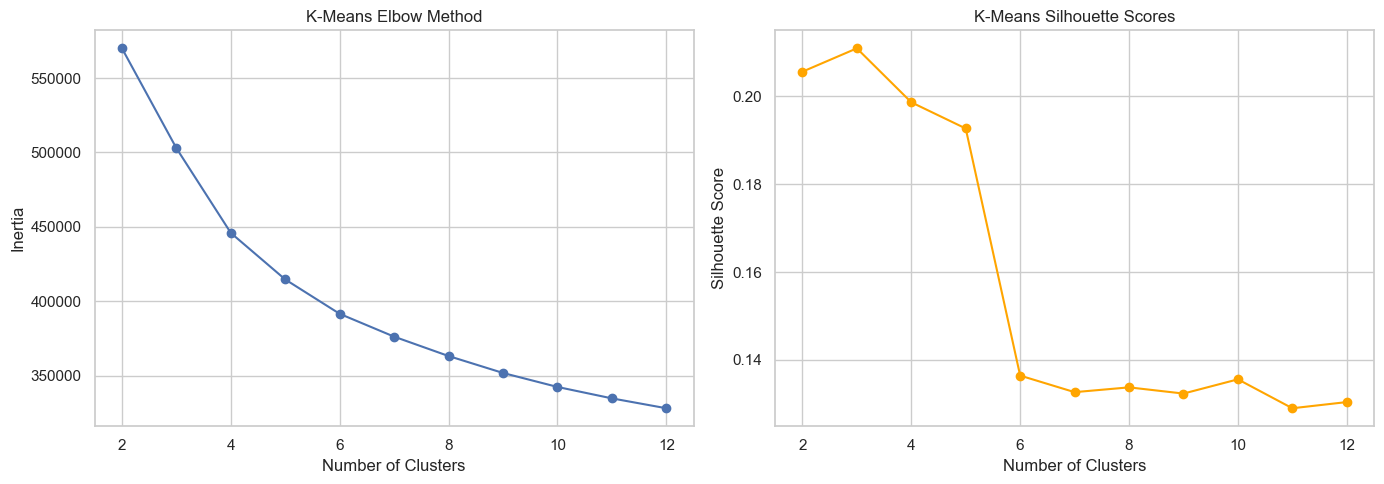

In [5]:
# Evaluate multiple k values using utils function
kmeans_results = clu.evaluate_multiple_kmeans(X, k_range=range(2, 13), random_state=42)
kmeans_results

clu.plot_elbow_and_silhouette(kmeans_results)

In [6]:
kmeans_comparison = clu.compare_kmeans_models(
    X, df, 
    k_values=[3, 4, 5, 6, 7], 
    random_state=42
)

# Access individual results if needed
k3_model = kmeans_comparison[3]["model"]
k3_labels = kmeans_comparison[3]["labels"]
k3_profile = kmeans_comparison[3]["profile"]
k3_metrics = kmeans_comparison[3]["metrics"]

--- KMEANS k=3 ---
Cluster distribution: {0: 6070, 1: 2940, 2: 23037}
Silhouette Score: 0.2110
--------------------------------------------------
--- KMEANS k=4 ---
Cluster distribution: {0: 2900, 1: 6225, 2: 3494, 3: 19428}
Silhouette Score: 0.1987
--------------------------------------------------
--- KMEANS k=5 ---
Cluster distribution: {0: 17798, 1: 5570, 2: 3259, 3: 2555, 4: 2865}
Silhouette Score: 0.1927
--------------------------------------------------
--- KMEANS k=6 ---
Cluster distribution: {0: 2162, 1: 7666, 2: 3189, 3: 11446, 4: 4830, 5: 2754}
Silhouette Score: 0.1364
--------------------------------------------------
--- KMEANS k=7 ---
Cluster distribution: {0: 3596, 1: 4667, 2: 9801, 3: 3209, 4: 2655, 5: 6004, 6: 2115}
Silhouette Score: 0.1327
--------------------------------------------------


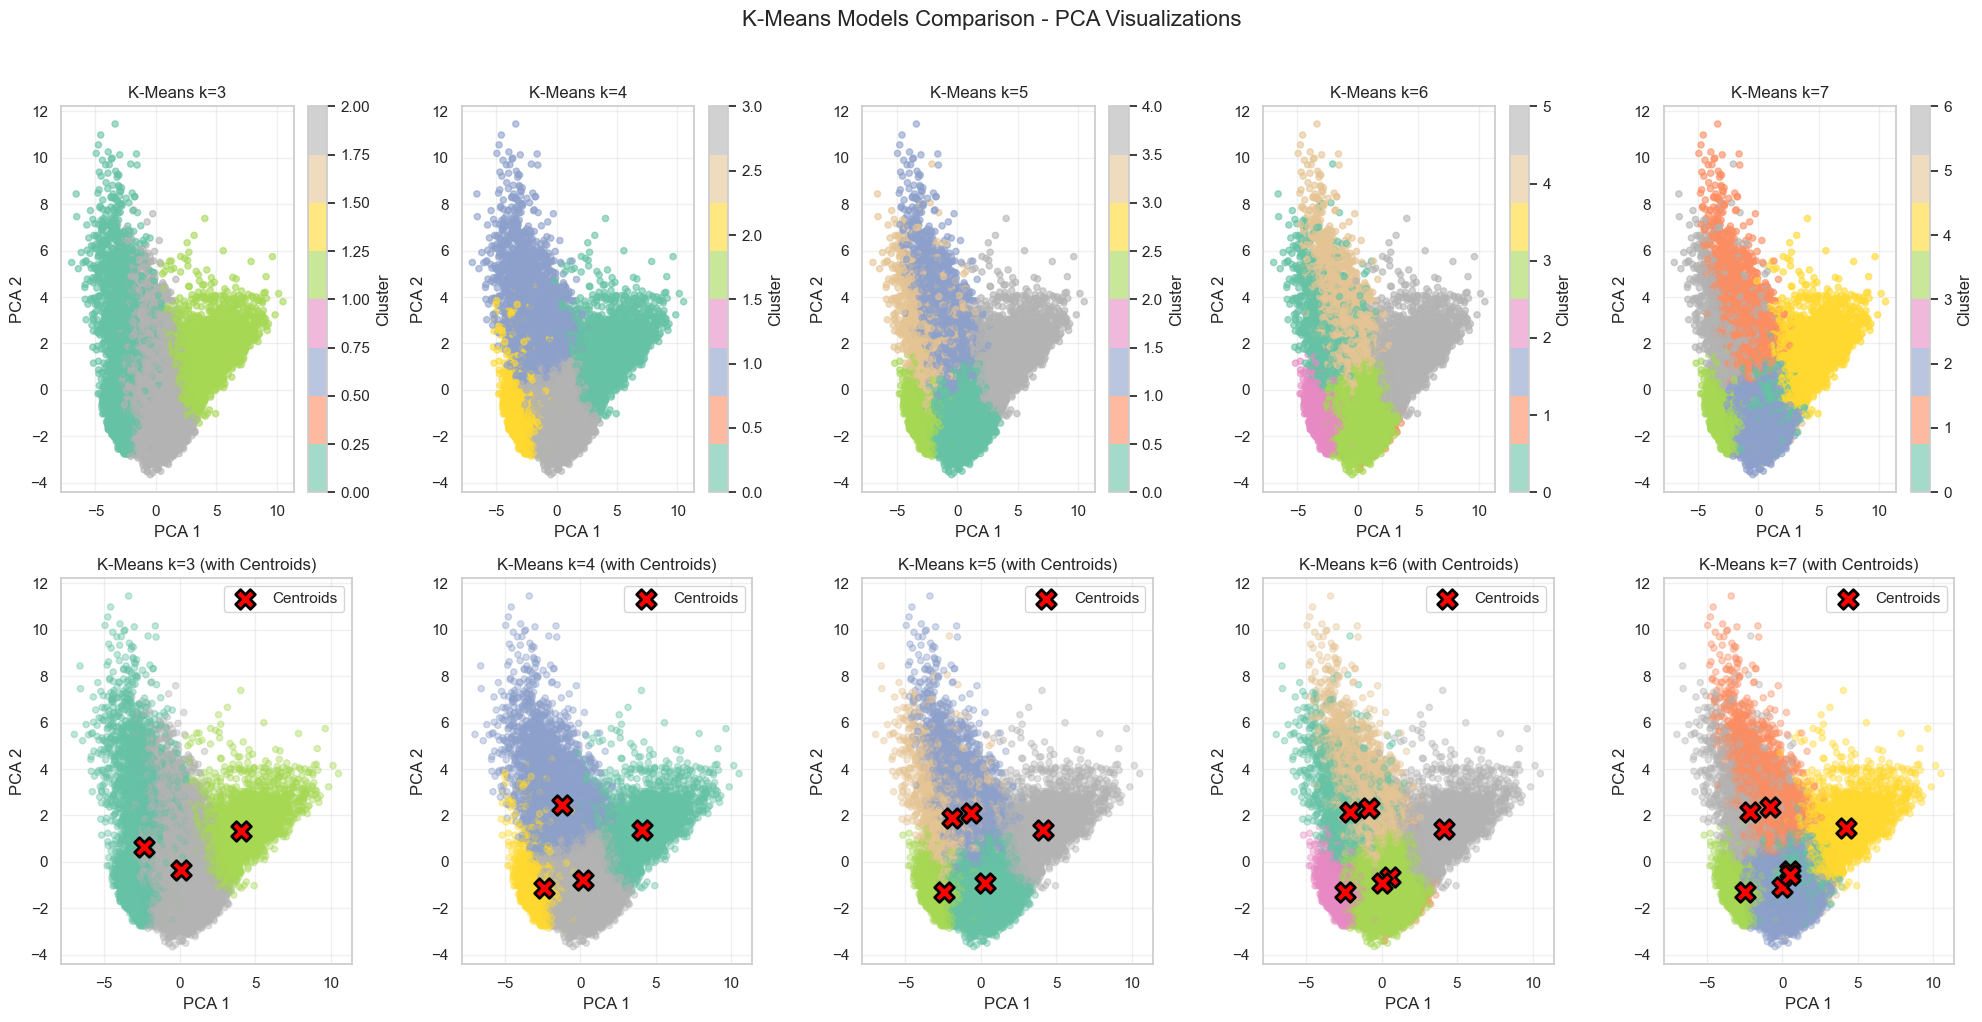

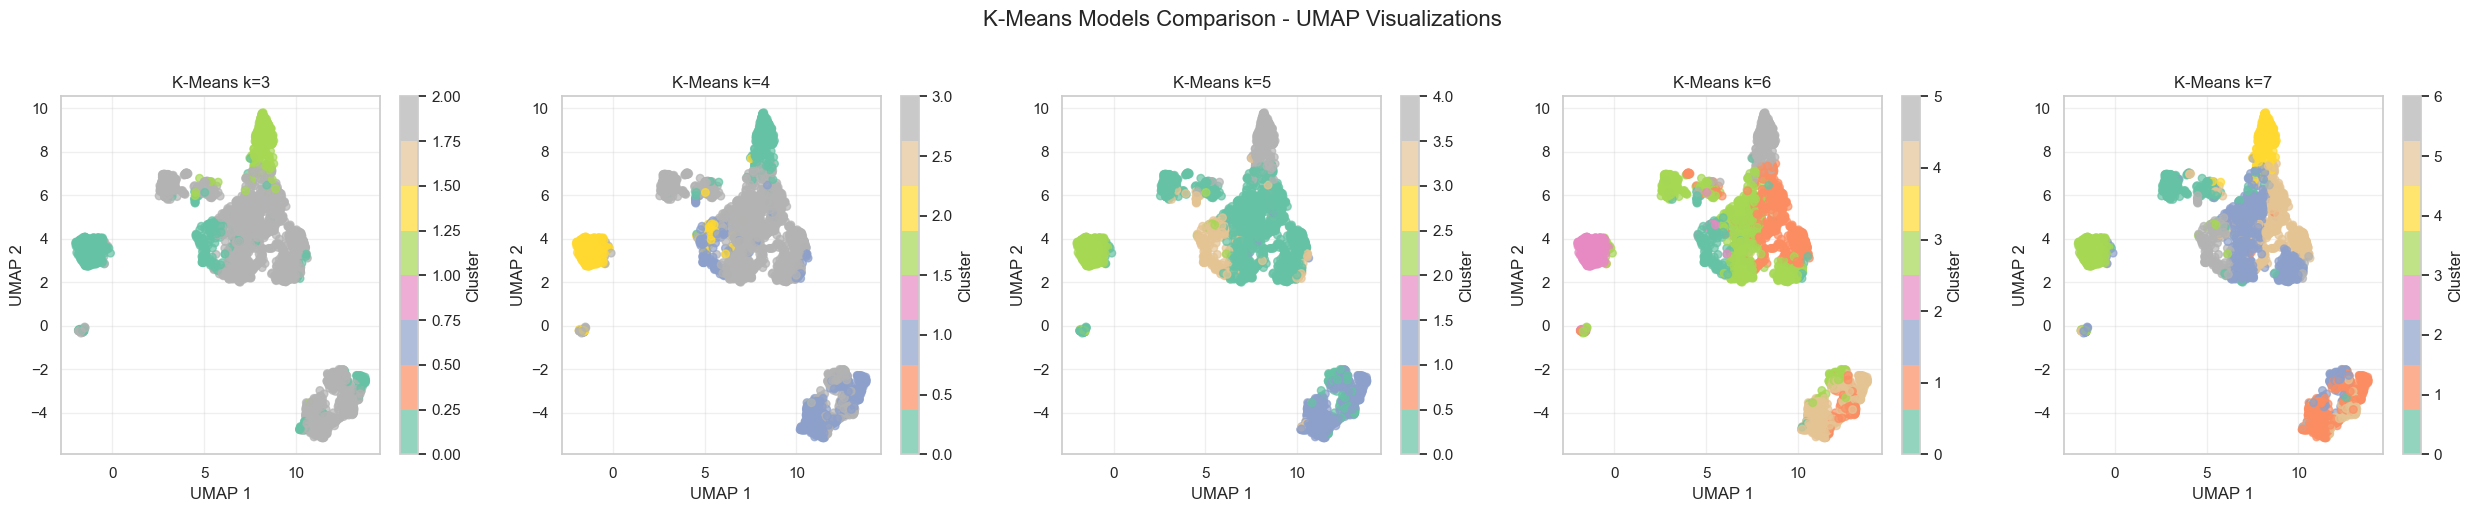

In [7]:
clu.plot_kmeans_pca_comparison(kmeans_comparison, X, k_values=[3, 4, 5, 6, 7])
clu.plot_kmeans_umap_comparison(kmeans_comparison, X, k_values=[3, 4, 5, 6, 7], sample_size=3000, random_state=42)

Explained variance with 2 components: 0.3328


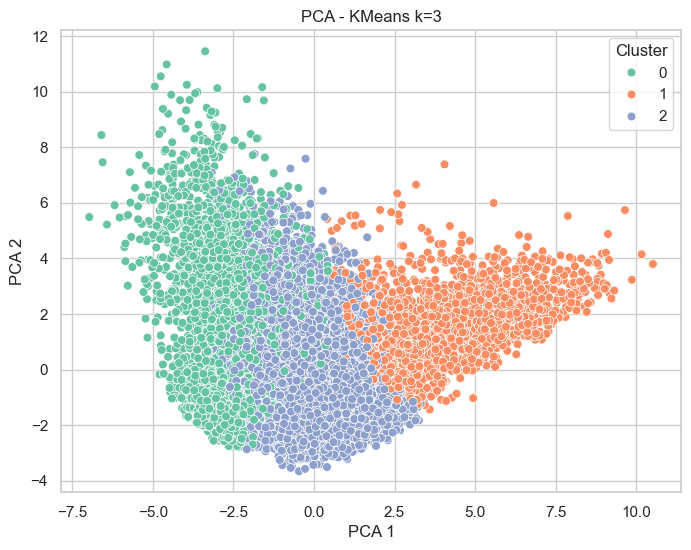

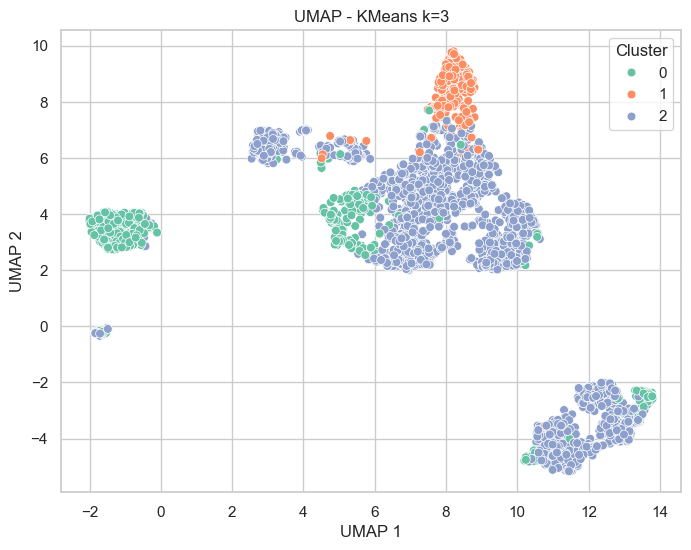

Explained variance with 2 components: 0.3328


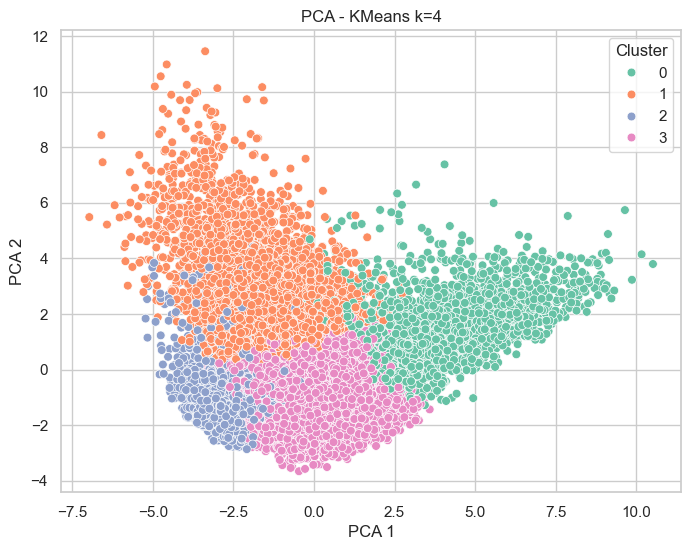

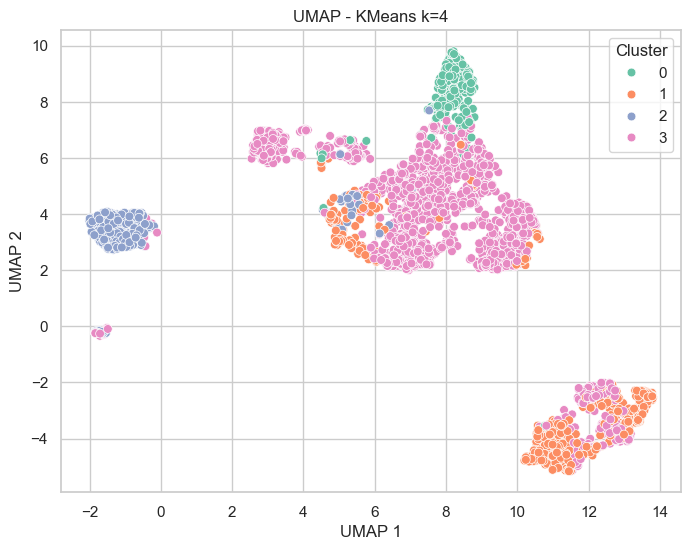

Explained variance with 2 components: 0.3328


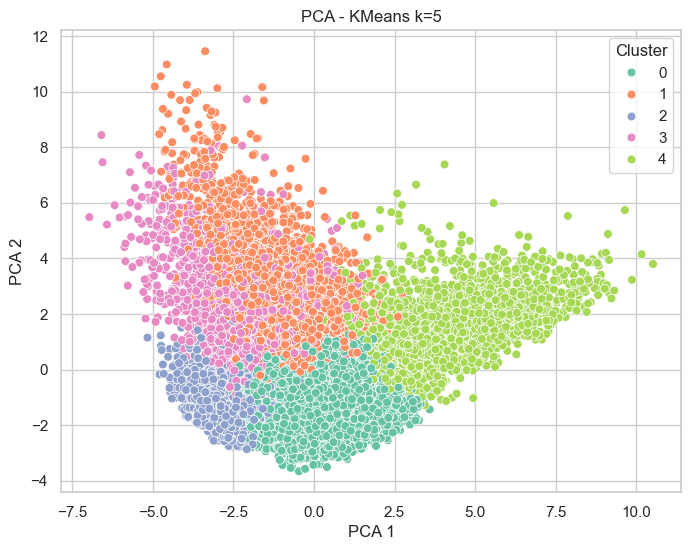

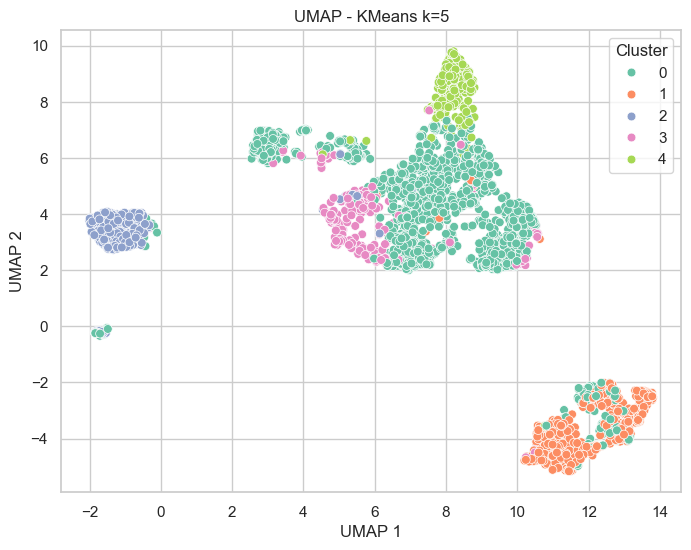

Explained variance with 2 components: 0.3328


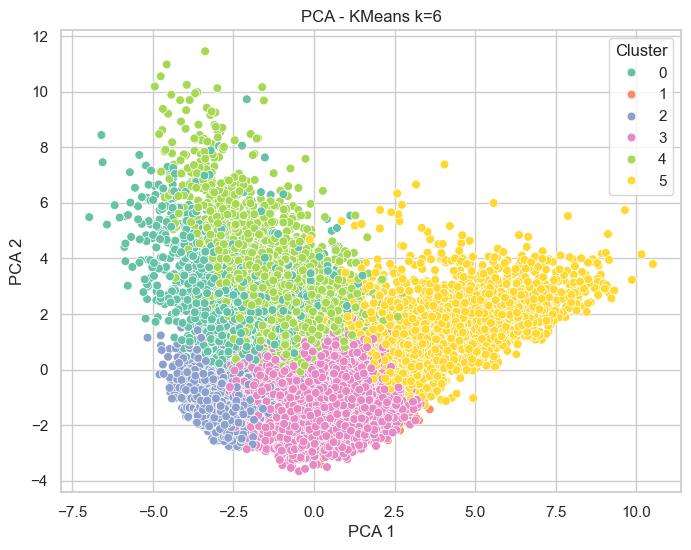

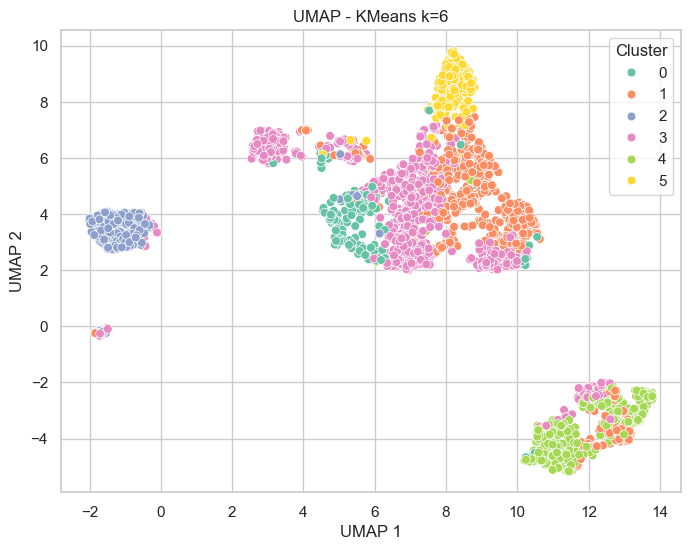

Explained variance with 2 components: 0.3328


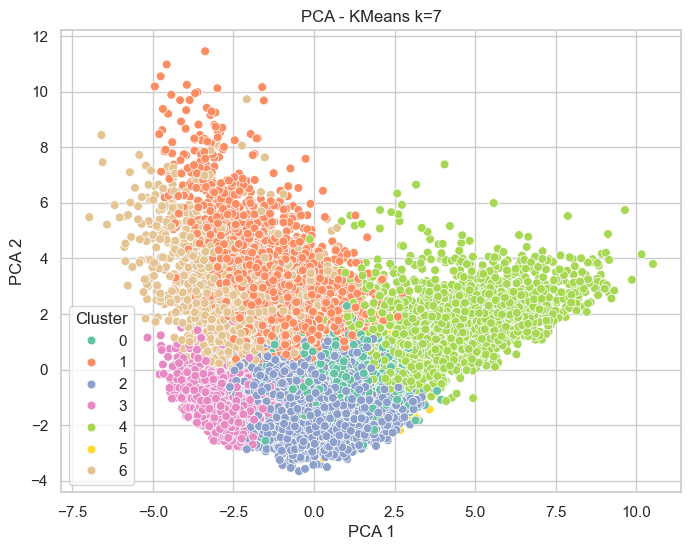

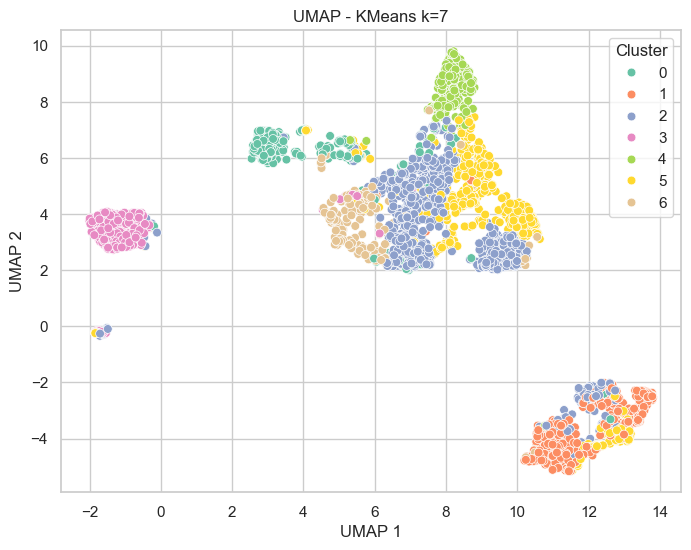

In [8]:
for k in [3, 4, 5, 6, 7]:
    labels = kmeans_comparison[k]["labels"]
    clu.plot_pca_clusters(X, labels, title=f"PCA - KMeans k={k}")
    clu.plot_umap_clusters(X, labels, title=f"UMAP - KMeans k={k}", sample_size=3000, random_state=42)

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>4. Final K-Means Model</b></h3>
</div>


In [9]:
best_k = 4

kmeans_model, kmeans_labels = clu.train_kmeans_final(X, n_clusters=best_k, random_state=42)

customer_info_kmeans = df.copy()
customer_info_kmeans["kmeans_cluster"] = kmeans_labels

In [10]:
cluster_dist = clu.cluster_distribution(kmeans_labels)
print("Cluster distribution:")
print(cluster_dist)

Cluster distribution:
0     2900
1     6225
2     3494
3    19428
Name: count, dtype: int64


In [11]:
kmeans_metrics = clu.evaluate_clustering(X, kmeans_labels, model_name=f"KMeans k={best_k}")
kmeans_metrics

kmeans_profile = clu.create_cluster_profile(customer_info_kmeans, cluster_col="kmeans_cluster")
kmeans_profile

,cluster_size,cluster_percentage,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,...,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend,customer_loyalty_flag,is_male,education_level
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,2900,9.05,-0.03,0.10,1.19,-0.11,-0.01,-0.00,0.29,-0.41,...,0.67,0.35,0.48,-0.12,-0.31,0.56,0.79,0.67,0.51,1.15
1,6225,19.42,-0.29,0.26,-0.04,-0.09,0.19,0.36,0.03,-0.09,...,0.21,0.08,0.03,1.87,1.16,0.32,-0.72,0.62,0.50,1.32
2,3494,10.90,0.04,-0.70,-0.08,0.08,-0.01,-0.42,-0.34,1.02,...,0.99,0.36,0.60,-0.45,-0.04,3.24,0.11,0.47,0.47,0.09
3,19428,60.62,-0.04,0.17,0.15,0.43,0.02,0.06,0.08,0.12,...,0.02,0.08,0.06,0.04,0.05,-0.11,0.13,0.61,0.50,0.92


In [12]:
customer_info_kmeans[selected_features].head()

,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,tenure,...,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend,customer_loyalty_flag,is_male,education_level
0,0.0,0.0,0.461538,1.049243,1.455070,-1.721835,0.007571,0.387135,0.032258,-0.833333,...,-0.428387,-0.939982,-0.422289,-0.036330,0.388199,1.474706,-0.129218,1,0,1
1,-1.0,-0.5,0.048951,-0.311199,0.107128,-0.668808,-0.108516,-0.394586,-0.161290,0.333333,...,-0.588546,-0.920384,-0.798877,1.676601,1.240944,-0.205284,-0.008434,1,0,1
2,-1.0,-0.5,-0.293706,-0.539294,1.021173,-0.116301,0.189469,-0.767327,-0.032258,1.666667,...,-0.492515,1.587951,-0.207940,0.042597,-0.057266,-0.702100,-0.383969,0,1,2
3,1.0,-1.0,-0.216783,-0.018275,-0.276669,0.232794,-0.732051,0.823443,-0.387097,-1.000000,...,1.770413,1.070404,1.720415,0.038006,-0.194939,0.835713,-0.439805,1,1,0
4,2.0,-1.0,-0.818182,-0.207611,-0.481052,-0.918785,-0.707107,0.397198,0.032258,-1.000000,...,0.179318,0.323009,0.557727,-0.528892,0.139499,3.290097,0.338048,1,1,0


In [13]:
cluster_profile = customer_info_kmeans.groupby("kmeans_cluster")[selected_features].mean()

cluster_profile

,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,tenure,...,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend,customer_loyalty_flag,is_male,education_level
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.032759,0.104655,1.191449,-0.106159,-0.009357,-0.000015,0.291378,-0.411698,0.092937,0.364310,...,0.671670,0.353250,0.482292,-0.120305,-0.308261,0.558490,0.794840,0.674828,0.510345,1.145862
1,-0.290924,0.263133,-0.035411,-0.090588,0.189948,0.363576,0.034997,-0.086053,0.097339,-0.044659,...,0.208849,0.081255,0.034364,1.867391,1.158521,0.323443,-0.724300,0.623775,0.503614,1.318554
2,0.042072,-0.696480,-0.078492,0.078711,-0.009343,-0.423538,-0.337315,1.023007,0.033420,-0.325701,...,0.992704,0.362711,0.604501,-0.451033,-0.041353,3.244444,0.105766,0.465655,0.474242,0.086148
3,-0.039942,0.167593,0.150030,0.430286,0.019883,0.062927,0.077569,0.118681,-0.027454,0.040792,...,0.015330,0.081491,0.056108,0.035825,0.053824,-0.106419,0.125684,0.612106,0.499176,0.915277


In [14]:
for cluster in cluster_profile.index:
    print(f"\nCluster {cluster} - Most defining features")
    
    top_features = cluster_profile.loc[cluster].abs().sort_values(ascending=False).head(10)
    
    display(pd.DataFrame({
        "feature": top_features.index,
        "mean_scaled_value": cluster_profile.loc[cluster, top_features.index].values,
        "absolute_value": top_features.values
    }))


Cluster 0 - Most defining features


,feature,mean_scaled_value,absolute_value
0,total_children,4.387931,4.387931
1,lifetime_total_distinct_products,1.191449,1.191449
2,education_level,1.145862,1.145862
3,log_total_spend,0.794840,0.794840
4,customer_loyalty_flag,0.674828,0.674828
5,pct_spend_alcohol_drinks,0.671670,0.671670
6,pct_spend_technology,0.558490,0.558490
7,is_male,0.510345,0.510345
8,pct_spend_fish,0.482292,0.482292
9,typical_hour_cos,-0.411698,0.411698



Cluster 1 - Most defining features


,feature,mean_scaled_value,absolute_value
0,pct_spend_vegetables,1.951992,1.951992
1,pct_spend_hygiene,1.867391,1.867391
2,education_level,1.318554,1.318554
3,pct_spend_nonalcohol_drinks,1.304310,1.304310
4,pct_spend_petfood,1.158521,1.158521
5,pct_spend_groceries,-0.947397,0.947397
6,log_total_spend,-0.724300,0.724300
7,customer_loyalty_flag,0.623775,0.623775
8,is_male,0.503614,0.503614
9,longitude,0.363576,0.363576



Cluster 2 - Most defining features


,feature,mean_scaled_value,absolute_value
0,pct_spend_technology,3.244444,3.244444
1,pct_spend_groceries,-1.731262,1.731262
2,total_children,-1.421007,1.421007
3,typical_hour_cos,1.023007,1.023007
4,pct_spend_alcohol_drinks,0.992704,0.992704
5,distinct_stores_visited,-0.696480,0.696480
6,pct_spend_fish,0.604501,0.604501
7,is_male,0.474242,0.474242
8,customer_loyalty_flag,0.465655,0.465655
9,pct_spend_hygiene,-0.451033,0.451033



Cluster 3 - Most defining features


,feature,mean_scaled_value,absolute_value
0,education_level,0.915277,0.915277
1,customer_loyalty_flag,0.612106,0.612106
2,is_male,0.499176,0.499176
3,percentage_of_products_bought_promotion,0.430286,0.430286
4,total_children,-0.329576,0.329576
5,pct_spend_groceries,0.239162,0.239162
6,distinct_stores_visited,0.167593,0.167593
7,pct_spend_nonalcohol_drinks,-0.160517,0.160517
8,lifetime_total_distinct_products,0.150030,0.150030
9,pct_spend_vegetables,0.138526,0.138526


Cluster 3 looks much less defined than the others. Its strongest value is only 0.915 for education_level, while clusters 0, 1, and 2 have much stronger signals. That supports your idea of subdividing cluster 3.

Also the education level impacts the clusters too much. So we should remove it


In [15]:
centroids = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=selected_features
)

centroid_importance = centroids.var(axis=0).sort_values(ascending=False)

centroid_importance.head(15)

total_children                      6.644083
pct_spend_technology                2.304804
pct_spend_hygiene                   1.087291
pct_spend_vegetables                1.008672
pct_spend_groceries                 0.727996
pct_spend_petfood                   0.418923
log_total_spend                     0.386918
pct_spend_nonalcohol_drinks         0.380043
typical_hour_cos                    0.377991
lifetime_total_distinct_products    0.357594
education_level                     0.297768
pct_spend_alcohol_drinks            0.196275
distinct_stores_visited             0.195603
longitude                           0.105107
pct_spend_fish                      0.085259
dtype: float64

Now the variables that less impact the clusters

In [17]:
centroid_importance.sort_values(ascending=True).head(15)

is_male                                    0.000248
customer_age                               0.003445
customer_loyalty_flag                      0.008074
latitude                                   0.009169
number_complaints                          0.021032
pct_spend_meat                             0.025497
percentage_of_products_bought_promotion    0.062088
typical_hour_sin                           0.068272
tenure                                     0.080723
pct_spend_fish                             0.085259
longitude                                  0.105107
distinct_stores_visited                    0.195603
pct_spend_alcohol_drinks                   0.196275
education_level                            0.297768
lifetime_total_distinct_products           0.357594
dtype: float64

In [18]:
for cluster in cluster_profile.index:
    print(f"\nCluster {cluster} - Least defining features")
    
    least_features = cluster_profile.loc[cluster].abs().sort_values(ascending=True).head(10)
    
    display(pd.DataFrame({
        "feature": least_features.index,
        "mean_scaled_value": cluster_profile.loc[cluster, least_features.index].values,
        "absolute_value": least_features.values
    }))


Cluster 0 - Least defining features


,feature,mean_scaled_value,absolute_value
0,longitude,-0.000015,0.000015
1,latitude,-0.009357,0.009357
2,pct_spend_vegetables,0.029411,0.029411
3,number_complaints,-0.032759,0.032759
4,customer_age,0.092937,0.092937
5,distinct_stores_visited,0.104655,0.104655
6,percentage_of_products_bought_promotion,-0.106159,0.106159
7,pct_spend_hygiene,-0.120305,0.120305
8,pct_spend_nonalcohol_drinks,0.258069,0.258069
9,pct_spend_groceries,-0.277070,0.277070



Cluster 1 - Least defining features


,feature,mean_scaled_value,absolute_value
0,pct_spend_fish,0.034364,0.034364
1,typical_hour_sin,0.034997,0.034997
2,lifetime_total_distinct_products,-0.035411,0.035411
3,tenure,-0.044659,0.044659
4,pct_spend_meat,0.081255,0.081255
5,typical_hour_cos,-0.086053,0.086053
6,percentage_of_products_bought_promotion,-0.090588,0.090588
7,customer_age,0.097339,0.097339
8,latitude,0.189948,0.189948
9,total_children,-0.197108,0.197108



Cluster 2 - Least defining features


,feature,mean_scaled_value,absolute_value
0,latitude,-0.009343,0.009343
1,customer_age,0.033420,0.033420
2,pct_spend_petfood,-0.041353,0.041353
3,number_complaints,0.042072,0.042072
4,lifetime_total_distinct_products,-0.078492,0.078492
5,percentage_of_products_bought_promotion,0.078711,0.078711
6,education_level,0.086148,0.086148
7,log_total_spend,0.105766,0.105766
8,pct_spend_vegetables,-0.256772,0.256772
9,tenure,-0.325701,0.325701



Cluster 3 - Least defining features


,feature,mean_scaled_value,absolute_value
0,pct_spend_alcohol_drinks,0.015330,0.015330
1,latitude,0.019883,0.019883
2,customer_age,-0.027454,0.027454
3,pct_spend_hygiene,0.035825,0.035825
4,number_complaints,-0.039942,0.039942
5,tenure,0.040792,0.040792
6,pct_spend_petfood,0.053824,0.053824
7,pct_spend_fish,0.056108,0.056108
8,longitude,0.062927,0.062927
9,typical_hour_sin,0.077569,0.077569


We can see that the location features: (Latitute, Longitude) don't impact too much. another thing is the Gender (is_male). So we should remove them

In [19]:
# Features to remove
features_to_remove = [
    "latitude",
    "longitude",
    "is_male",
    "education_level"
]

# New feature list without those variables
selected_features_v2 = [
    feature for feature in selected_features
    if feature not in features_to_remove
]

print("Old number of features:", len(selected_features))
print("New number of features:", len(selected_features_v2))
print("Removed features:", features_to_remove)

Old number of features: 24
New number of features: 20
Removed features: ['latitude', 'longitude', 'is_male', 'education_level']


Now we train the model without the old features


In [21]:
X_v2 = customer_info_kmeans[selected_features_v2].copy()

In [22]:
# Evaluate multiple k values for the new feature set
kmeans_results_v2 = clu.evaluate_multiple_kmeans(
    X_v2,
    k_range=range(2, 13),
    random_state=42
)

kmeans_results_v2

,k,inertia,silhouette_score
0,2,483239.893673,0.225808
1,3,416576.134112,0.240135
2,4,362205.911922,0.231965
3,5,331959.867499,0.221072
4,6,313064.191763,0.158097
5,7,298641.707418,0.157751
6,8,284355.726242,0.162789
7,9,273897.180520,0.150428
8,10,265364.516625,0.155354
9,11,257866.928581,0.157846


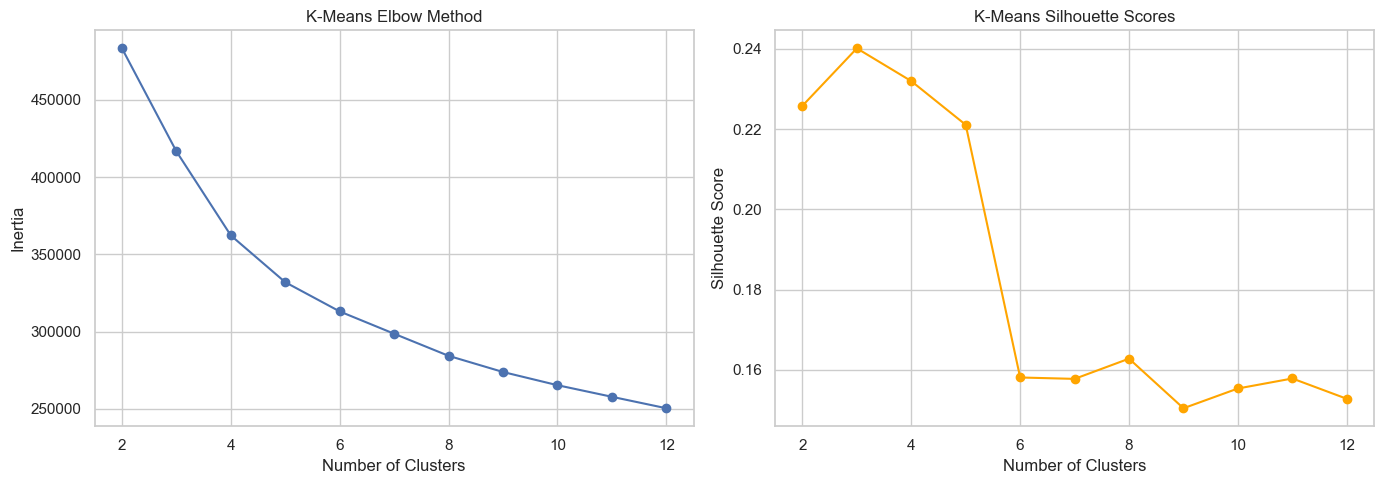

In [23]:
clu.plot_elbow_and_silhouette(kmeans_results_v2)

We see that k = 3 or 4 is still the best option

## Subcluster the clusters

From the k = 4 clusters, with the old features. we see that cluster 3 is huge with almost 50% of customers, and cluster 1 has some negative sillhuette values. This suggests that the clusters can still be divided better. So we will conduct seperate k means on those 2 clusters.

In [24]:
# First create a copy of Cluster 1 and Cluster 3

# Separate Cluster 1
cluster_1_df = customer_info_kmeans[
    customer_info_kmeans["kmeans_cluster"] == 1
].copy()

# Separate Cluster 3
cluster_3_df = customer_info_kmeans[
    customer_info_kmeans["kmeans_cluster"] == 3
].copy()

print("Cluster 1 shape:", cluster_1_df.shape)
print("Cluster 3 shape:", cluster_3_df.shape)

Cluster 1 shape: (6225, 26)
Cluster 3 shape: (19428, 26)


In [25]:
# Now create the X data for each one, using the original selected features:

X_cluster_1 = cluster_1_df[selected_features].copy()
X_cluster_3 = cluster_3_df[selected_features].copy()

### For Cluster 1

In [27]:
kmeans_results_cluster_1 = clu.evaluate_multiple_kmeans(
    X_cluster_1,
    k_range=range(2, 8),
    random_state=42
)

kmeans_results_cluster_1

,k,inertia,silhouette_score
0,2,108874.026627,0.256885
1,3,96929.035043,0.147200
2,4,90432.058736,0.126612
3,5,84983.801718,0.130759
4,6,80747.807204,0.124088
5,7,77426.477144,0.129499


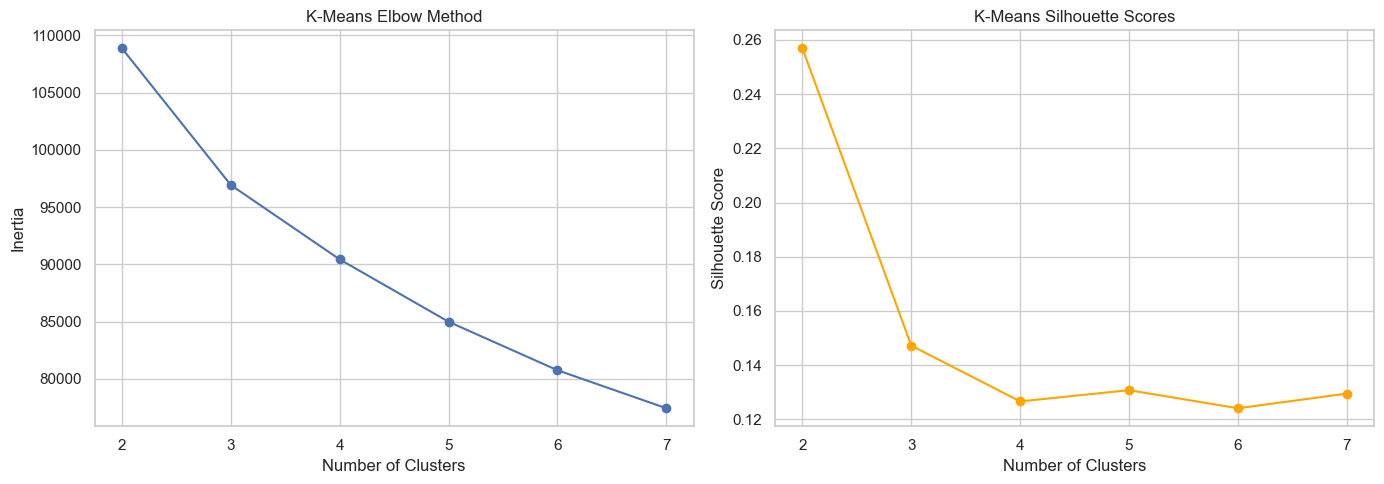

In [29]:
clu.plot_elbow_and_silhouette(kmeans_results_cluster_1)

### For Cluster 3

In [28]:
kmeans_results_cluster_3 = clu.evaluate_multiple_kmeans(
    X_cluster_3,
    k_range=range(2, 8),
    random_state=42
)

kmeans_results_cluster_3

,k,inertia,silhouette_score
0,2,211165.055349,0.101441
1,3,196261.173291,0.096235
2,4,184347.726013,0.102860
3,5,177106.763767,0.093052
4,6,170975.944923,0.092547
5,7,165947.323512,0.098172


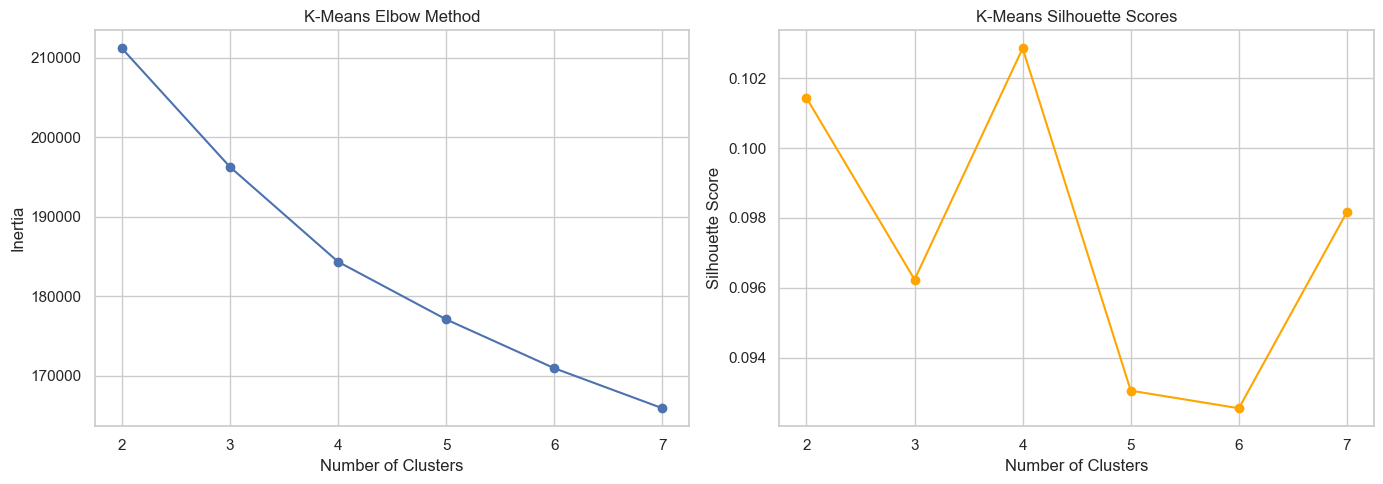

In [30]:
clu.plot_elbow_and_silhouette(kmeans_results_cluster_3)

Lets divide Cluster 1 into 2, and Cluster 3 into 4

In [31]:
# Cluster 1 → divide into 2 subclusters
best_k_cluster_1 = 2

kmeans_sub_1, sub_labels_1 = clu.train_kmeans_final(
    X_cluster_1,
    n_clusters=best_k_cluster_1,
    random_state=42
)

cluster_1_df["sub_cluster"] = sub_labels_1
cluster_1_df["final_cluster"] = cluster_1_df["sub_cluster"].apply(lambda x: f"1_{x}")

In [32]:
# Cluster 3 → divide into 4 subclusters
best_k_cluster_3 = 4

kmeans_sub_3, sub_labels_3 = clu.train_kmeans_final(
    X_cluster_3,
    n_clusters=best_k_cluster_3,
    random_state=42
)

cluster_3_df["sub_cluster"] = sub_labels_3
cluster_3_df["final_cluster"] = cluster_3_df["sub_cluster"].apply(lambda x: f"3_{x}")

The final destribution will become:

cluster 0 stays as 0\
cluster 2 stays as 2\
cluster 1 becomes 1_0, 1_1\
cluster 3 becomes 3_0, 3_1, 3_2, 3_3

In [33]:
# Start from the original k=4 dataframe
customer_info_final = customer_info_kmeans.copy()

# By default, keep original cluster labels as strings
customer_info_final["final_cluster"] = customer_info_final["kmeans_cluster"].astype(str)

# Replace cluster 1 labels with subcluster labels
customer_info_final.loc[
    customer_info_final["kmeans_cluster"] == 1,
    "final_cluster"
] = cluster_1_df["final_cluster"].values

# Replace cluster 3 labels with subcluster labels
customer_info_final.loc[
    customer_info_final["kmeans_cluster"] == 3,
    "final_cluster"
] = cluster_3_df["final_cluster"].values

In [34]:
customer_info_final["final_cluster"].value_counts().sort_index()

final_cluster
0      2900
1_0    1610
1_1    4615
2      3494
3_0    3124
3_1    5336
3_2    4061
3_3    6907
Name: count, dtype: int64

In [ ]:
final_cluster_profile = customer_info_final.groupby("final_cluster")[selected_features].mean()

final_cluster_profile

,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,tenure,...,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend,customer_loyalty_flag,is_male,education_level
final_cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.032759,0.104655,1.191449,-0.106159,-0.009357,-0.000015,0.291378,-0.411698,0.092937,0.364310,...,0.671670,0.353250,0.482292,-0.120305,-0.308261,0.558490,0.794840,0.674828,0.510345,1.145862
1_0,-0.115528,0.381988,0.186926,0.568180,0.047065,0.044705,0.008174,0.125369,0.119760,0.083644,...,0.824638,2.264235,1.641692,1.567241,2.332971,0.519038,-1.237916,0.690062,0.494410,0.995031
1_1,-0.352113,0.221668,-0.112976,-0.320407,0.239795,0.474818,0.044355,-0.159810,0.089517,-0.089419,...,-0.005976,-0.680305,-0.526372,1.972102,0.748799,0.255207,-0.545118,0.600650,0.506826,1.431419
2,0.042072,-0.696480,-0.078492,0.078711,-0.009343,-0.423538,-0.337315,1.023007,0.033420,-0.325701,...,0.992704,0.362711,0.604501,-0.451033,-0.041353,3.244444,0.105766,0.465655,0.474242,0.086148
3_0,1.239757,-0.379641,-0.324494,0.737312,-0.009025,-0.042224,0.290468,-0.195519,-0.517591,-0.362303,...,0.627627,0.251544,0.316608,-0.020291,0.310100,-0.069491,-0.397795,0.416773,0.506722,0.196863
3_1,-0.240630,0.188156,0.356746,0.201474,0.039959,0.092430,0.090495,0.156871,0.063595,0.175725,...,-0.111218,-0.125173,-0.011666,0.059597,-0.103630,-0.084299,0.387232,0.874438,0.511057,2.527736
3_2,-0.303620,0.541615,-0.270070,1.071746,-0.043286,0.008433,-0.163972,0.311958,0.003498,-0.132028,...,0.008713,0.769986,0.182560,0.034571,0.481642,-0.206804,-0.463077,0.668308,0.481409,0.367643
3_3,-0.308672,0.179311,0.451956,0.091040,0.054589,0.119735,0.113306,0.117651,0.105695,0.220477,...,-0.159955,-0.240569,-0.083703,0.043578,-0.191985,-0.081189,0.506558,0.464746,0.497032,0.316491


In [36]:
for cluster in final_cluster_profile.index:
    print(f"\nFinal Cluster {cluster} - Most defining features")
    
    top_features = final_cluster_profile.loc[cluster].abs().sort_values(ascending=False).head(10)
    
    display(pd.DataFrame({
        "feature": top_features.index,
        "mean_scaled_value": final_cluster_profile.loc[cluster, top_features.index].values,
        "absolute_value": top_features.values
    }))


Final Cluster 0 - Most defining features


,feature,mean_scaled_value,absolute_value
0,total_children,4.387931,4.387931
1,lifetime_total_distinct_products,1.191449,1.191449
2,education_level,1.145862,1.145862
3,log_total_spend,0.794840,0.794840
4,customer_loyalty_flag,0.674828,0.674828
5,pct_spend_alcohol_drinks,0.671670,0.671670
6,pct_spend_technology,0.558490,0.558490
7,is_male,0.510345,0.510345
8,pct_spend_fish,0.482292,0.482292
9,typical_hour_cos,-0.411698,0.411698



Final Cluster 1_0 - Most defining features


,feature,mean_scaled_value,absolute_value
0,pct_spend_petfood,2.332971,2.332971
1,pct_spend_meat,2.264235,2.264235
2,pct_spend_fish,1.641692,1.641692
3,pct_spend_hygiene,1.567241,1.567241
4,pct_spend_nonalcohol_drinks,1.528603,1.528603
5,pct_spend_groceries,-1.489698,1.489698
6,log_total_spend,-1.237916,1.237916
7,education_level,0.995031,0.995031
8,pct_spend_vegetables,0.867859,0.867859
9,pct_spend_alcohol_drinks,0.824638,0.824638



Final Cluster 1_1 - Most defining features


...

,feature,mean_scaled_value,absolute_value
0,education_level,2.527736,2.527736
1,customer_loyalty_flag,0.874438,0.874438
2,is_male,0.511057,0.511057
3,log_total_spend,0.387232,0.387232
4,lifetime_total_distinct_products,0.356746,0.356746
5,total_children,-0.355322,0.355322
6,pct_spend_groceries,0.281336,0.281336
7,number_complaints,-0.240630,0.240630
8,percentage_of_products_bought_promotion,0.201474,0.201474
9,distinct_stores_visited,0.188156,0.188156



Final Cluster 3_2 - Most defining features


,feature,mean_scaled_value,absolute_value
0,percentage_of_products_bought_promotion,1.071746,1.071746
1,total_children,-1.071411,1.071411
2,pct_spend_meat,0.769986,0.769986
3,customer_loyalty_flag,0.668308,0.668308
4,distinct_stores_visited,0.541615,0.541615
5,pct_spend_petfood,0.481642,0.481642
6,is_male,0.481409,0.481409
7,log_total_spend,-0.463077,0.463077
8,education_level,0.367643,0.367643
9,typical_hour_cos,0.311958,0.311958



Final Cluster 3_3 - Most defining features


,feature,mean_scaled_value,absolute_value
0,log_total_spend,0.506558,0.506558
1,is_male,0.497032,0.497032
2,customer_loyalty_flag,0.464746,0.464746
3,lifetime_total_distinct_products,0.451956,0.451956
4,pct_spend_groceries,0.321158,0.321158
5,education_level,0.316491,0.316491
6,number_complaints,-0.308672,0.308672
7,total_children,-0.279716,0.279716
8,pct_spend_meat,-0.240569,0.240569
9,tenure,0.220477,0.220477


<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>5. Silhouette Analysis</b></h3>
</div>



The silhouette plot shows how well each customer fits within its assigned cluster compared with the nearest alternative cluster. In customer segmentation, moderate silhouette values are common because real customer behavior is complex and overlapping.

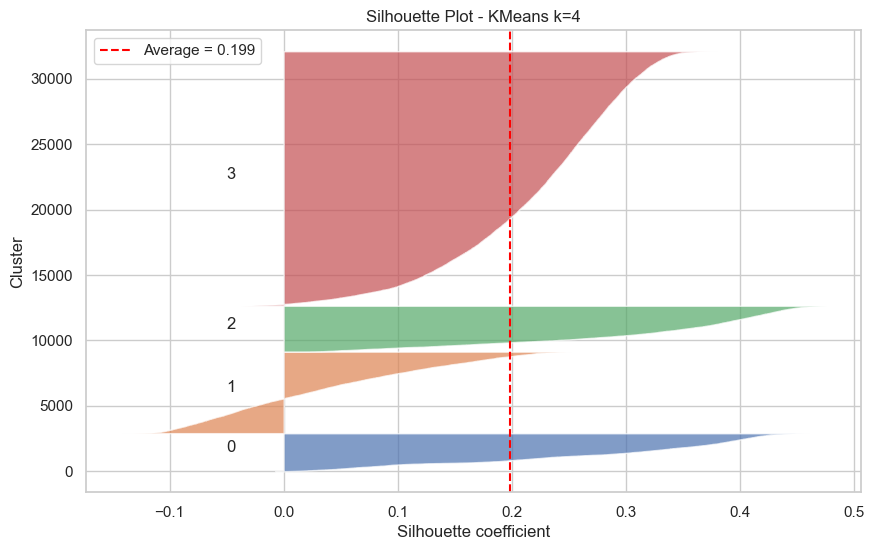

In [28]:
clu.plot_silhouette_analysis(
    X,
    kmeans_labels,
    title="Silhouette Plot - KMeans k=4"
)

In [33]:
top_cluster_features = clu.get_top_cluster_features(
    kmeans_profile,
    top_n=5
)

top_cluster_features

,cluster,top_positive_features,top_negative_features
0,0,"[total_children, lifetime_total_distinct_produ...","[percentage_of_products_bought_promotion, pct_..."
1,1,"[pct_spend_vegetables, pct_spend_hygiene, educ...","[typical_hour_cos, total_children, number_comp..."
2,2,"[pct_spend_technology, typical_hour_cos, pct_s...","[longitude, pct_spend_hygiene, distinct_stores..."
3,3,"[education_level, customer_loyalty_flag, is_ma...","[customer_age, number_complaints, pct_spend_te..."


In [37]:
# Add cluster labels to dataframe
customer_info_kmeans["kmeans_cluster"] = kmeans_labels

profile_features = [
    "kmeans_cluster",

    "number_complaints",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "latitude",
    "longitude",
    "typical_hour_sin",
    "typical_hour_cos",
    "customer_age",
    "tenure",
    "total_children",

    "pct_spend_groceries",
    "pct_spend_vegetables",
    "pct_spend_nonalcohol_drinks",
    "pct_spend_alcohol_drinks",
    "pct_spend_meat",
    "pct_spend_fish",
    "pct_spend_hygiene",
    "pct_spend_petfood",
    "pct_spend_technology",

    "log_total_spend",

    "customer_loyalty_flag",
    "is_male",
    "education_level"
]

profile_df = customer_info_kmeans[profile_features]

cluster_std = profile_df.groupby("kmeans_cluster").std()

display(cluster_std)

,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,tenure,...,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend,customer_loyalty_flag,is_male,education_level
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,0.932323,0.877842,0.740713,0.331507,0.728369,0.686194,0.329982,0.441903,0.530109,0.879136,...,0.674867,0.571296,0.660776,0.411106,0.492276,0.494327,0.459710,0.468520,0.499979,1.149606
1,0.782412,0.771020,0.507851,0.603398,0.714450,1.024925,0.490942,0.795787,0.538326,0.640956,...,0.898427,1.570813,1.223963,1.415991,1.429558,0.843515,0.587606,0.484476,0.500027,1.178979
2,0.866201,0.457738,0.515153,0.443876,0.585930,0.554669,0.432241,1.055320,0.559089,0.531618,...,0.902808,0.713393,0.880377,0.462043,0.649210,1.245417,0.492902,0.498890,0.499408,0.420308
3,0.918095,0.826693,0.713894,0.811841,0.719341,0.787692,0.529131,0.861945,0.578263,0.787848,...,0.659978,0.715742,0.624800,0.549842,0.687675,0.469869,0.691678,0.487283,0.500012,1.134868


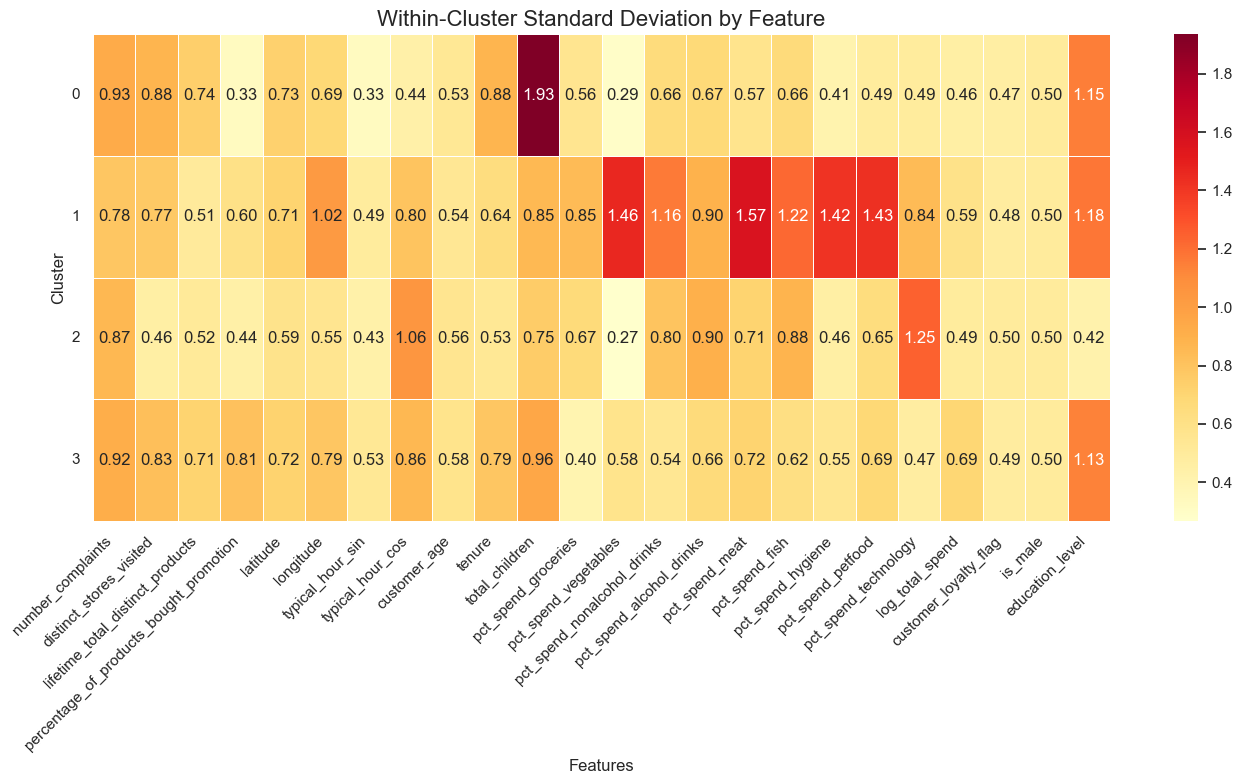

In [38]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    cluster_std,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Within-Cluster Standard Deviation by Feature",
    fontsize=16
)

plt.xlabel("Features")
plt.ylabel("Cluster")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

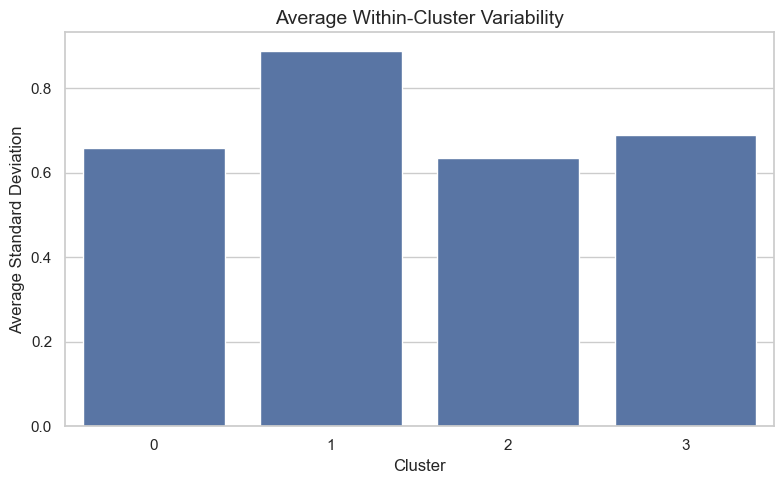

In [39]:
cluster_std["average_std"] = cluster_std.mean(axis=1)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_std.index,
    y=cluster_std["average_std"]
)

plt.title(
    "Average Within-Cluster Variability",
    fontsize=14
)

plt.xlabel("Cluster")
plt.ylabel("Average Standard Deviation")

plt.tight_layout()
plt.show()

Which variables impact clustering more:

## 10. PCA, t-SNE and UMAP Visualizations

Dimensionality reduction techniques are used only for visualization. They help assess whether the final K-Means segments show coherent separation in lower-dimensional spaces.

Explained variance with 2 components: 0.3372


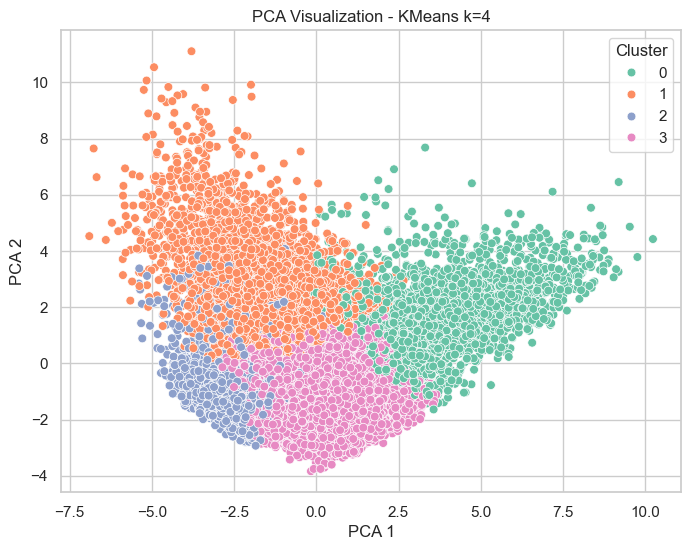

In [17]:
embedding, pca_model = clu.plot_pca_clusters(
    X,
    kmeans_labels,
    title="PCA Visualization - KMeans k=4"
)

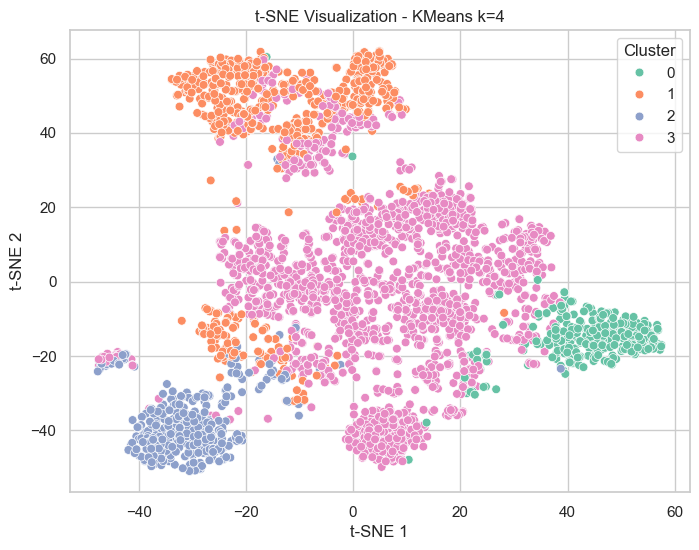

In [18]:
tsne_embedding = clu.plot_tsne_clusters(
    X, 
    kmeans_labels, 
    title="t-SNE Visualization - KMeans k=4",
    sample_size=3000, 
    perplexity=30, 
    random_state=42
)

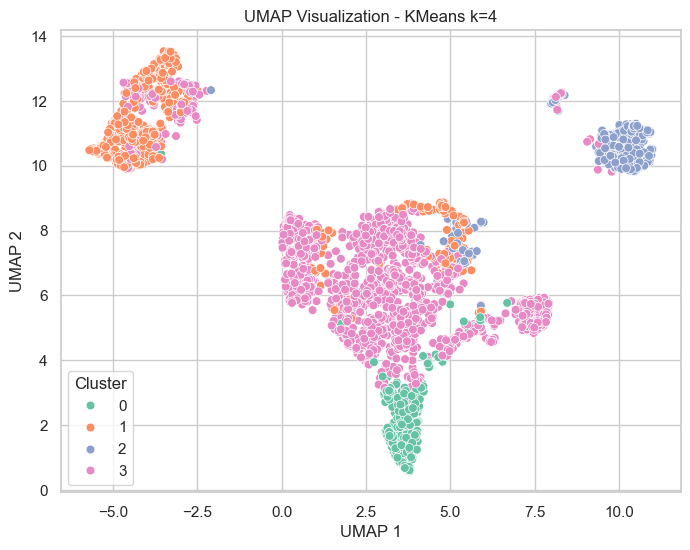

In [19]:
umap_embedding = clu.plot_umap_clusters(
    X, 
    kmeans_labels, 
    title="UMAP Visualization - KMeans k=4",
    sample_size=3000, 
    n_neighbors=15, 
    min_dist=0.1, 
    random_state=42
)

## 12. Hierarchical Clustering

Hierarchical clustering was tested as an alternative method to validate whether a similar segmentation structure could be found using a different clustering approach.

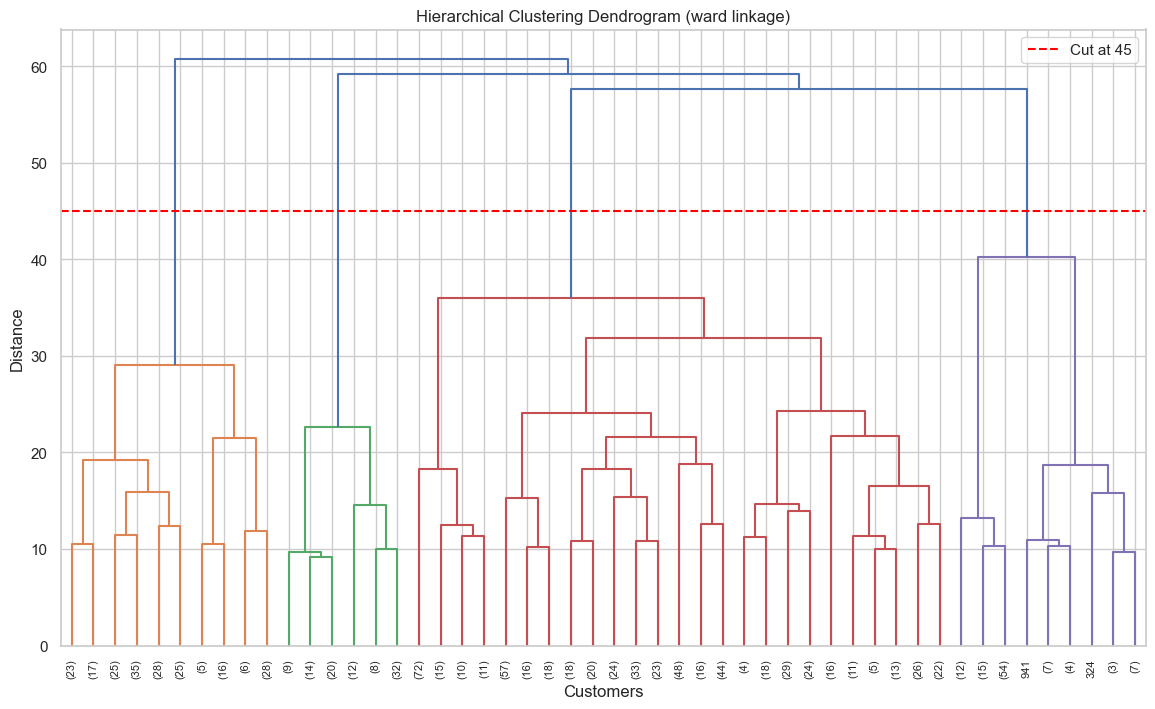

In [35]:
linkage_matrix = clu.plot_dendrogram_sample(
    X, 
    sample_size=1000, 
    method="ward", 
    truncate_p=50, 
    cut_line=45,
    random_state=42
)

The dendrogram suggests a reasonable partition around five groups, supporting the `k=4` segmentation used in the final K-Means model.

Cluster distribution:
0     8924
1    16948
2     3102
3     3073
Name: count, dtype: int64
Explained variance with 2 components: 0.3372


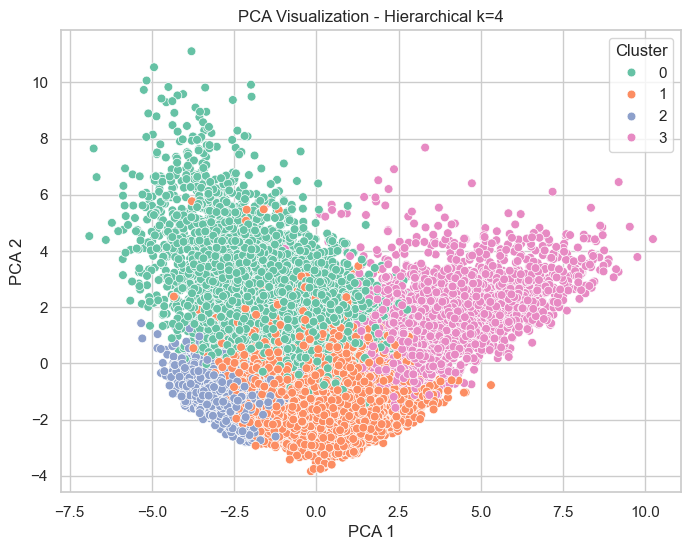

In [36]:
hier_results = clu.run_hierarchical_clustering(X, n_clusters=4, linkage_method="ward")

hier_labels = hier_results["labels"]
hier_model = hier_results["model"]
hier_metrics = hier_results["metrics"]
hier_distribution = hier_results["cluster_distribution"]

customer_info_hier = df.copy()
customer_info_hier["hierarchical_cluster"] = hier_labels

print("Cluster distribution:")
print(hier_distribution)

hier_metrics

_ = clu.plot_pca_clusters(
    X,
    hier_labels,
    title="PCA Visualization - Hierarchical k=4"
)

In [37]:
hier_metrics = clu.evaluate_clustering(
    X,
    hier_labels,
    model_name="Hierarchical k=4"
)

hier_metrics

,Model,Clusters,Silhouette Score
0,Hierarchical k=4,4,0.159963


## 13. K-Means vs Hierarchical Agreement

This heatmap compares the final K-Means solution with the Hierarchical Clustering solution. Strong concentration in specific cells indicates that the methods identify similar structures.

In [ ]:
cluster_agreement = clu.plot_cluster_agreement_heatmap(
    customer_info_kmeans.assign(hierarchical_cluster=hier_labels),
    col1="kmeans_cluster",
    col2="hierarchical_cluster",
    title="KMeans vs Hierarchical Cluster Agreement"
)

cluster_agreement.round(2)

## 14. DBSCAN

DBSCAN was tested as a density-based clustering method. It is useful when clusters have clear density separation, but it can struggle with high-dimensional customer datasets and heterogeneous densities.

In [ ]:
dbscan_results = clu.run_dbscan_analysis(X, eps=1.5, min_samples=10, title="DBSCAN")

dbscan_labels = dbscan_results["labels"]
dbscan_model = dbscan_results["model"]
dbscan_metrics = dbscan_results["metrics"]
dbscan_distribution = dbscan_results["cluster_distribution"]

customer_info_dbscan = df.copy()
customer_info_dbscan["dbscan_cluster"] = dbscan_labels

print("Cluster distribution:")
print(dbscan_distribution)

dbscan_metrics

_ = clu.plot_pca_clusters(
    X,
    dbscan_labels,
    title="PCA Visualization - DBSCAN"
)

## 15. Mean Shift

Mean Shift was also tested as a density-based method. Because it can be computationally expensive, it was evaluated on a sample of the dataset.

In [ ]:
meanshift_results = clu.run_meanshift_analysis(
    X, 
    sample_size=5000, 
    quantile=0.2, 
    bin_seeding=True, 
    random_state=42
)

meanshift_labels = meanshift_results["labels"]
meanshift_model = meanshift_results["model"]
meanshift_metrics = meanshift_results["metrics"]
bandwidth = meanshift_results["bandwidth"]
meanshift_distribution = meanshift_results["cluster_distribution"]
X_meanshift_sample = meanshift_results["sample_used"]

print(f"Bandwidth: {bandwidth:.4f}")
print("\nCluster distribution:")
print(meanshift_distribution)

meanshift_metrics

_ = clu.plot_pca_clusters(
    X_meanshift_sample,
    meanshift_labels,
    title="PCA Visualization - Mean Shift"
)

In [ ]:
meanshift_metrics = clu.evaluate_clustering(
    X_meanshift_sample,
    meanshift_labels,
    model_name="Mean Shift"
)

meanshift_metrics

## 16. Model Comparison

The final model comparison uses Silhouette Score as the quantitative metric. However, model selection also considers interpretability, cluster size balance and usefulness for customer segmentation.

In [ ]:
# Option 1: Keep as is (works fine)
comparison = pd.concat(
    [
        kmeans_metrics,
        hier_metrics,
        dbscan_metrics,
        meanshift_metrics
    ],
    ignore_index=True
)

comparison

# Option 2: Use utils function (more elegant)
model_results = {
    "KMeans": {"metrics": kmeans_metrics},
    "Hierarchical": {"metrics": hier_metrics},
    "DBSCAN": {"metrics": dbscan_metrics},
    "Mean Shift": {"metrics": meanshift_metrics}
}
comparison = clu.compare_all_models(X, model_results)
comparison

# Print recommendation
best_model = clu.print_model_recommendation(comparison, primary_metric="Silhouette Score")

In [ ]:
customer_info_kmeans = clu.add_recommendations(
    customer_info_kmeans,
    name_col="segment_name",
    action_col="recommended_action"
)

segment_recommendations = (
    customer_info_kmeans[["segment_name", "recommended_action"]]
    .drop_duplicates()
    .sort_values("segment_name")
)

segment_recommendations

In [ ]:
customer_info_kmeans[[
    "customer_id",
    "kmeans_cluster",
    "segment_name",
    "recommended_action"
]].head()

## 19. Export Final Results

The final outputs are exported for later use in cluster characterization, basket analysis and marketing strategy.

In [ ]:
# Ensure customer_id is stored as an integer identifier when possible
for _df in [customer_info_kmeans, final_clustered_dataset]:
    if "customer_id" in _df.columns:
        _df["customer_id"] = _df["customer_id"].astype(int)

output_dir = "../datasets"
os.makedirs(output_dir, exist_ok=True)

final_clustered_dataset.to_csv(
    os.path.join(output_dir, "customer_segments_final.csv"),
    index=False
)

customer_info_kmeans[[
    "customer_id",
    "kmeans_cluster",
    "segment_name",
    "recommended_action"
]].to_csv(
    os.path.join(output_dir, "customer_segments_main_only.csv"),
    index=False
)

kmeans_profile.to_csv(
    os.path.join(output_dir, "kmeans_cluster_profile.csv")
)

comparison.to_csv(
    os.path.join(output_dir, "clustering_model_comparison.csv"),
    index=False
)

print("Final clustering files exported successfully.")